In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from itertools import combinations
import os

In [4]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "../.."))

df = pd.read_csv(os.path.join(BASE_DIR, "data", "death_rate.csv"))
print(df.info())
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              850 non-null    int64  
 1   state             850 non-null    object 
 2   sex               850 non-null    object 
 3   age_group         850 non-null    object 
 4   age_group_detail  850 non-null    object 
 5   race              850 non-null    object 
 6   hydro_gms         850 non-null    float64
 7   oxy_gms           850 non-null    float64
 8   fent_gms          850 non-null    float64
 9   unempl_rate       850 non-null    float64
 10  poverty_rate      850 non-null    float64
 11  gsp               850 non-null    float64
 12  min_wage          850 non-null    float64
 13  snap_rate         850 non-null    float64
 14  medicaid_rate     850 non-null    float64
 15  gov_dem           850 non-null    int64  
 16  death_rate        850 non-null    float64
dt

,year,state,sex,age_group,age_group_detail,race,hydro_gms,oxy_gms,fent_gms,unempl_rate,poverty_rate,gsp,min_wage,snap_rate,medicaid_rate,gov_dem,death_rate
0,2000,AL,Both Sexes,All Ages,All Ages,All Races,10664.777495,6724.566122,62.816442,4.6,13.3,120132.9,5.15,0.088958,0.126888,1,4.4857
1,2001,AL,Both Sexes,All Ages,All Ages,All Races,11269.214757,7735.814080,62.527727,5.1,15.9,123035.3,5.15,0.092060,0.150865,1,4.8915
2,2002,AL,Both Sexes,All Ages,All Ages,All Races,12882.256134,8232.095445,83.428979,5.9,14.5,128117.4,5.15,0.099004,0.164526,1,4.7619
3,2003,AL,Both Sexes,All Ages,All Ages,All Races,14451.140460,8704.414975,103.961016,6.0,15.0,133969.3,5.15,0.104822,0.166062,0,4.4333
4,2004,AL,Both Sexes,All Ages,All Ages,All Races,15990.254107,9164.085680,124.175547,5.7,16.9,146886.7,5.15,0.109826,0.172655,0,6.3542


In [3]:
# Drop demographic cols
df = df.drop(columns=['sex', 'race', 'age_group', 'age_group_detail']).reset_index(drop=True)
df.head()

,year,state,hydro_gms,oxy_gms,fent_gms,unempl_rate,poverty_rate,gsp,min_wage,snap_rate,medicaid_rate,gov_dem,death_rate
0,2000,AL,10664.777495,6724.566122,62.816442,4.6,13.3,120132.9,5.15,0.088958,0.126888,1,4.4857
1,2001,AL,11269.214757,7735.814080,62.527727,5.1,15.9,123035.3,5.15,0.092060,0.150865,1,4.8915
2,2002,AL,12882.256134,8232.095445,83.428979,5.9,14.5,128117.4,5.15,0.099004,0.164526,1,4.7619
3,2003,AL,14451.140460,8704.414975,103.961016,6.0,15.0,133969.3,5.15,0.104822,0.166062,0,4.4333
4,2004,AL,15990.254107,9164.085680,124.175547,5.7,16.9,146886.7,5.15,0.109826,0.172655,0,6.3542


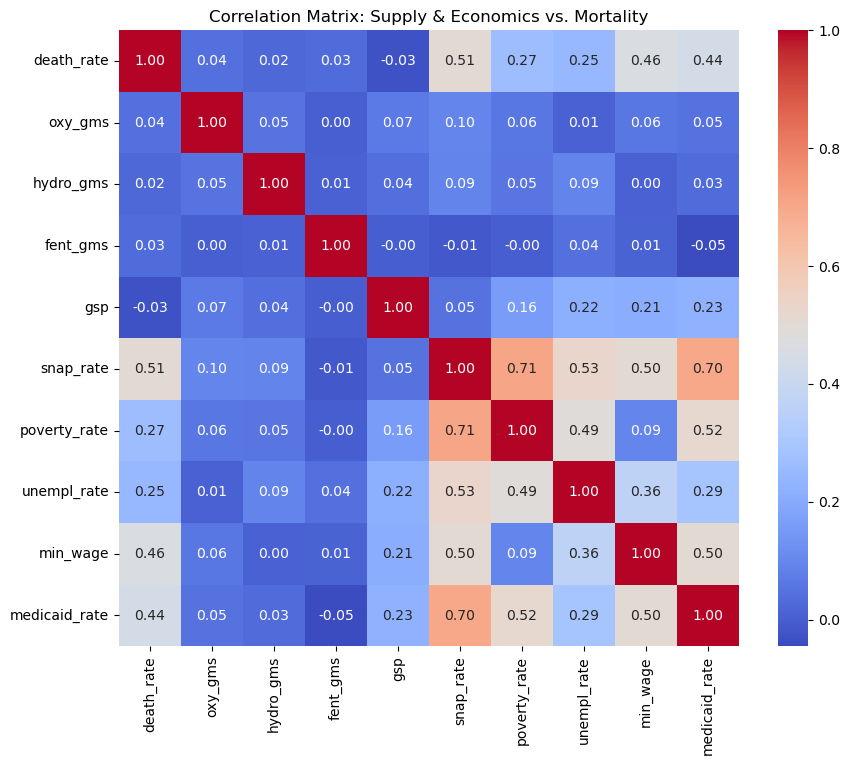

In [4]:
# Correlation
# Select variables for correlation
cols_to_corr = ['death_rate', 'oxy_gms', 'hydro_gms', 'fent_gms', 'gsp', 'snap_rate',
                'poverty_rate', 'unempl_rate', 'min_wage', 'medicaid_rate']

plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_to_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Supply & Economics vs. Mortality")
plt.show()

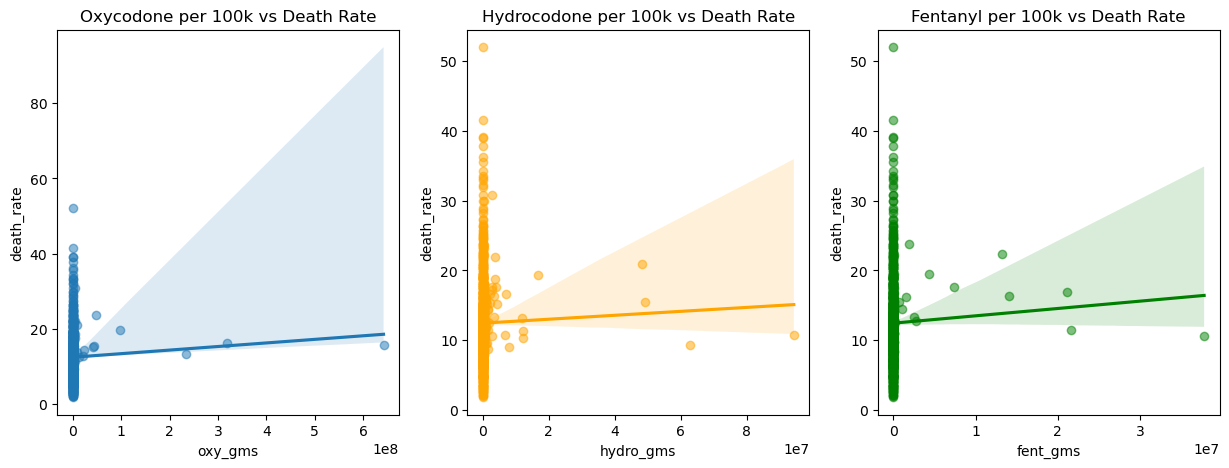

In [5]:
# Scatter plots for oxy_gms and hydro_gms vs death_rate

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

sns.regplot(data=df, x='oxy_gms', y='death_rate', ax=ax1, scatter_kws={'alpha':0.5})
ax1.set_title('Oxycodone per 100k vs Death Rate')

sns.regplot(data=df, x='hydro_gms', y='death_rate', ax=ax2, scatter_kws={'alpha':0.5}, color='orange')
ax2.set_title('Hydrocodone per 100k vs Death Rate')

sns.regplot(data=df, x='fent_gms', y='death_rate', ax=ax3, scatter_kws={'alpha':0.5}, color='green')
ax3.set_title('Fentanyl per 100k vs Death Rate')

plt.show()

In [19]:
df.head()

,year,state,hydro_gms,oxy_gms,unempl_rate,poverty_rate,gsp,min_wage,snap_rate,medicaid_rate,aca_exp,gov_dem,death_rate,log_oxy,log_hydro
0,2000,AL,10664.777495,6724.566122,4.6,13.3,120132.9,5.15,0.088958,0.126888,0.0,1,4.4857,8.813671,9.274796
1,2001,AL,12065.615178,7317.474753,5.1,15.9,123035.3,5.15,0.092060,0.150865,0.0,1,4.8915,8.898157,9.398198
2,2002,AL,13477.895908,7919.213212,5.9,14.5,128117.4,5.15,0.099004,0.164526,0.0,1,4.7619,8.977173,9.508880
3,2003,AL,14846.170182,8496.910730,6.0,15.0,133969.3,5.15,0.104822,0.166062,0.0,0,4.4333,9.047576,9.605565
4,2004,AL,16186.581541,9060.957298,5.7,16.9,146886.7,5.15,0.109826,0.172655,0.0,0,6.3542,9.111840,9.692000


In [6]:
# log transform the skewed features
df['log_oxy'] = np.log1p(df['oxy_gms'])
df['log_hydro'] = np.log1p(df['hydro_gms'])
df['log_fent'] = np.log1p(df['fent_gms'])

# separate features
# eliminating medicaid_rate because it is colinear with snap rate but snap rate has higher correlation with death rate
continuous_vars = ['log_oxy', 'log_hydro', 'log_fent', 'unempl_rate', 'poverty_rate', 'min_wage', 'gsp', 'snap_rate',
'death_rate']

# 3. SCALE SECOND: Put everything on a common -3 to +3 range
scaler = StandardScaler()
df[continuous_vars] = scaler.fit_transform(df[continuous_vars])

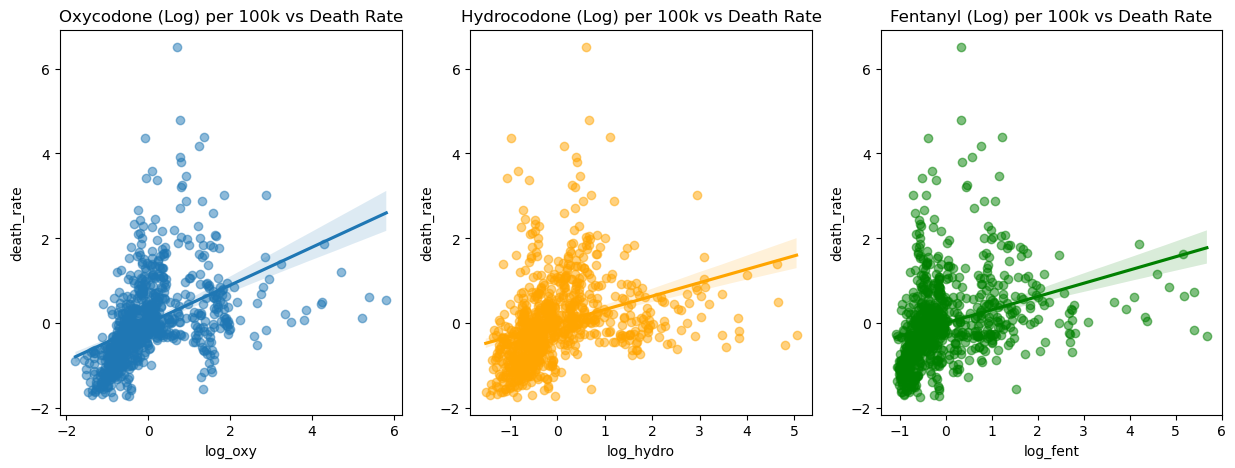

In [10]:
# Scatter plots for oxy_gms and hydro_gms vs death_rate

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

sns.regplot(data=df, x='log_oxy', y='death_rate', ax=ax1, scatter_kws={'alpha':0.5})
ax1.set_title('Oxycodone (Log) per 100k vs Death Rate')

sns.regplot(data=df, x='log_hydro', y='death_rate', ax=ax2, scatter_kws={'alpha':0.5}, color='orange')
ax2.set_title('Hydrocodone (Log) per 100k vs Death Rate')

sns.regplot(data=df, x='log_fent', y='death_rate', ax=ax3, scatter_kws={'alpha':0.5}, color='green')
ax3.set_title('Fentanyl (Log) per 100k vs Death Rate')

plt.show()

## Clustering

In [24]:
# Define the pool based on your pre-scaled columns
# Added 'gov_dem' as it's a binary categorical often useful in policy clustering
candidate_pool = [
    'log_oxy', 'log_hydro', 'log_fent', 
    'unempl_rate', 'poverty_rate', 'min_wage', 
    'gsp', 'snap_rate', 'death_rate', 'gov_dem'
]

def find_optimal_features(df, pool, min_features=3, max_features=6):
    results = []
    # Drop NaNs just for the calculation to avoid KMeans errors
    df_calc = df[pool].dropna()
    
    print(f"Testing combinations from {min_features} to {max_features} features...")
    
    for r in range(min_features, max_features + 1):
        for combo in combinations(pool, r):
            features = list(combo)
            
            # Use k=3 as the standard benchmark
            kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
            clusters = kmeans.fit_predict(df_calc[features])
            
            score = silhouette_score(df_calc[features], clusters)
            
            results.append({
                'feature_count': r,
                'features': features,
                'silhouette': score
            })
            
    return pd.DataFrame(results).sort_values(by='silhouette', ascending=False)

# Run the search
best_combinations = find_optimal_features(df, candidate_pool)

# Display top 10 results
print("\nTop 10 Feature Sets by Silhouette Score:")
print(best_combinations.head(10))

Testing combinations from 3 to 6 features...

Top 10 Feature Sets by Silhouette Score:
     feature_count                             features  silhouette
4                3            [log_oxy, log_hydro, gsp]    0.566566
11               3             [log_oxy, log_fent, gsp]    0.546198
39               3           [log_hydro, log_fent, gsp]    0.535061
60               3            [log_hydro, gsp, gov_dem]    0.518835
144              4   [log_oxy, log_hydro, gsp, gov_dem]    0.517439
123              4  [log_oxy, log_hydro, log_fent, gsp]    0.516162
14               3         [log_oxy, log_fent, gov_dem]    0.514911
81               3             [log_fent, gsp, gov_dem]    0.514566
32               3              [log_oxy, gsp, gov_dem]    0.513323
42               3       [log_hydro, log_fent, gov_dem]    0.502690


In [26]:
# Create two candidate clusterings
km_math = KMeans(n_clusters=3, random_state=42).fit_predict(df[['log_oxy', 'log_hydro', 'gsp']])
km_comprehensive = KMeans(n_clusters=3, random_state=42).fit_predict(df[['log_oxy', 'log_hydro', 'log_fent', 'gsp']])

df['cluster_math'] = km_math
df['cluster_comp'] = km_comprehensive

# Compare how they split the death rates
print("--- Math Winner (Set 4) ---")
print(df.groupby('cluster_math')[['death_rate', 'log_fent', 'gsp', 'snap_rate']].mean())

print("\n--- Comprehensive Set (Set 123) ---")
print(df.groupby('cluster_comp')[['death_rate', 'log_fent', 'gsp', 'snap_rate']].mean())

--- Math Winner (Set 4) ---
              death_rate  log_fent       gsp  snap_rate
cluster_math                                           
0              -0.115781 -0.260636 -0.280566  -0.188549
1               0.548244  1.004992  0.262397   0.723233
2              -0.435091  0.048721  3.728877   0.052289

--- Comprehensive Set (Set 123) ---
              death_rate  log_fent       gsp  snap_rate
cluster_comp                                           
0              -0.204711 -0.457542 -0.267712  -0.250470
1               0.622679  1.200535  0.066571   0.660162
2              -0.431608  0.118768  3.672773   0.048244


In [27]:
# Assuming 'cluster_comp' is saved in your dataframe
pd.crosstab(df['cluster_comp'], df['gov_dem'], normalize='index')

gov_dem,0,1
cluster_comp,,
0,0.571186,0.428814
1,0.538462,0.461538
2,0.487179,0.512821


In [13]:
df.columns

Index(['year', 'state', 'hydro_gms', 'oxy_gms', 'fent_gms', 'unempl_rate',
       'poverty_rate', 'gsp', 'min_wage', 'snap_rate', 'medicaid_rate',
       'gov_dem', 'death_rate', 'log_oxy', 'log_hydro', 'log_fent'],
      dtype='object')

In [21]:
feature_sets = {
    "v1_all_drugs": ['log_oxy', 'log_hydro', 'log_fent', 'snap_rate'],
    "v2_economic_focus": ['log_oxy', 'snap_rate', 'unempl_rate', 'gsp'],
    "v3_policy_risk": ['log_fent', 'snap_rate', 'min_wage', 'gov_dem']
}

def run_clustering(df, features, k=3):
    # Prepare data
    data = df[features].dropna()
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)
    
    # Fit Model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(scaled_data)
    
    # Score it
    score = silhouette_score(scaled_data, clusters)
    return clusters, score, data.index

# Test Version 1
features = feature_sets["v1_all_drugs"]
clusters, sil_score, idx = run_clustering(df, features, k=3)
df.loc[idx, 'cluster_v1'] = clusters

print(f"Silhouette Score for v1: {sil_score:.3f}")

# Test Version 2
features = feature_sets["v2_economic_focus"]
clusters, sil_score, idx = run_clustering(df, features, k=3)
df.loc[idx, 'cluster_v2'] = clusters

print(f"Silhouette Score for v2: {sil_score:.3f}")

# Test Version 3
features = feature_sets["v3_policy_risk"]
clusters, sil_score, idx = run_clustering(df, features, k=3)
df.loc[idx, 'cluster_v3'] = clusters

print(f"Silhouette Score for v3: {sil_score:.3f}")

Silhouette Score for v1: 0.353
Silhouette Score for v2: 0.391
Silhouette Score for v3: 0.330


In [22]:
# Group by the new clusters to see the "Story" of each group
analysis = df.groupby('cluster_v1')[['death_rate', 'snap_rate', 'log_fent', 'unempl_rate']].mean()
print(analysis)

            death_rate  snap_rate  log_fent  unempl_rate
cluster_v1                                              
0.0          -0.549637  -0.831200 -0.606349    -0.508373
1.0           0.451996   0.728684  1.308332     0.732757
2.0           0.422771   0.618974  0.101041     0.249035


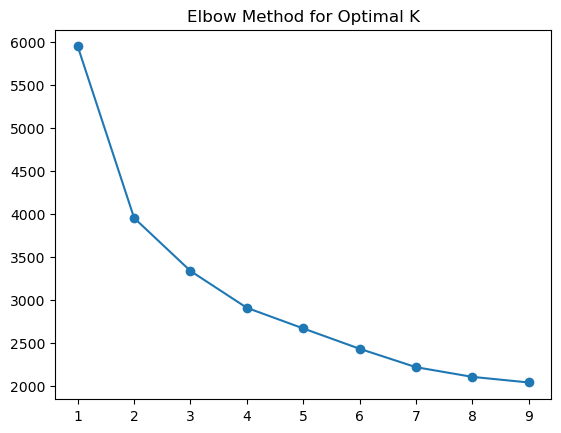

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Select the features (use the scaled versions!)
cluster_features = ['log_oxy', 'log_hydro', 'log_fent', 'unempl_rate', 'snap_rate',
                    'gsp', 'death_rate']
X = df[cluster_features]

# 2. Use the "Elbow Method" to find the right number of clusters
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.show()

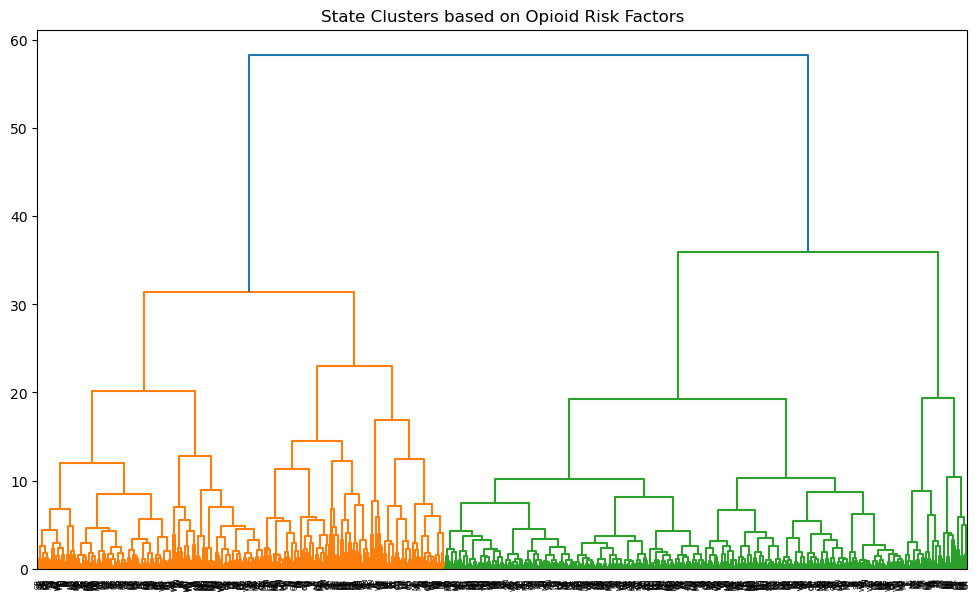

In [15]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Use 'ward' linkage to minimize variance within clusters
Z = linkage(X, method='ward')

plt.figure(figsize=(12, 7))
dendrogram(Z, labels=df['state'].values, leaf_rotation=90)
plt.title('State Clusters based on Opioid Risk Factors')
plt.show()

In [16]:
# 1. Fit the final model and grab the labels (not the distances)
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster_label'] = kmeans.fit_predict(X)  # Use fit_predict here

# view cluster summary
cluster_summary = df.groupby('cluster_label')[cluster_features].mean()
print(cluster_summary)

# see which states are in which cluster
for cluster in df['cluster_label'].unique():
    states = df[df['cluster_label'] == cluster]['state'].unique()
    print(f"States in Cluster {cluster}: {states}")

                log_oxy  log_hydro  log_fent  unempl_rate  snap_rate  \
cluster_label                                                          
0              0.129683   0.081578  0.120370     0.476310   0.757297   
1              1.735162   1.665388  1.463334     0.728611   0.788748   
2             -0.584958  -0.611316 -0.504263    -0.547874  -0.697835   
3              0.087072   0.917642  0.118768     0.493188   0.048244   

                    gsp  death_rate  
cluster_label                        
0             -0.262783    0.759515  
1              0.344082    0.496943  
2             -0.272545   -0.571706  
3              3.672773   -0.431608  
States in Cluster 2: ['AL' 'AK' 'AZ' 'AR' 'CO' 'CT' 'DE' 'FL' 'GA' 'HI' 'ID' 'IL' 'IN' 'IA'
 'KS' 'KY' 'LA' 'ME' 'MD' 'MA' 'MI' 'MN' 'MS' 'MO' 'MT' 'NE' 'NV' 'NH'
 'NJ' 'NM' 'NY' 'NC' 'ND' 'OH' 'OK' 'OR' 'PA' 'RI' 'SC' 'SD' 'TN' 'TX'
 'UT' 'VT' 'VA' 'WA' 'WV' 'WI' 'WY']
States in Cluster 0: ['AL' 'AK' 'AZ' 'AR' 'CO' 'CT' 'HI' 'ID' 'IL' '

In [17]:
import plotly.express as px

# 1. Create the 3D Scatter Plot
# Ensure you are using the unscaled original data for the plot labels!
fig = px.scatter_3d(df, x='oxy_gms', y='poverty_rate', z='death_rate',
                    color='cluster_label', # Color points by cluster
                    text='state', # Add state abbreviations to the points
                    title='3D State Risk Profiles',
                    labels={'oxy_gms': 'Oxy supply per 100k',
                            'poverty_rate': 'Poverty Rate (%)',
                            'death_rate': 'Opioid Death Rate'},
                    opacity=0.8)

# 2. Make the markers large and clear
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

# 3. Use log scale on Oxy axis to handle the extreme outliers we saw earlier
fig.update_layout(scene=dict(xaxis=dict(type="log")))

fig.show()

In [45]:
import plotly.express as px

# 1. We need a clean mapping of Cluster Label (0, 1, 2) to names for the legend
cluster_map = {0: 'Low Risk/Stable', 1: 'Supply Epicenter (High Death)', 2: 'Economic Vulnerability'}
df['cluster_name'] = df['cluster_label'].map(cluster_map)

# 2. Create the Choropleth Map
fig = px.choropleth(df,
                    locations='state', # State column (must have AB codes like AL, KY, WV)
                    locationmode="USA-states", # Use built-in US map
                    color='cluster_name', # Fill colors by the cluster names we just created
                    color_discrete_sequence=["#2ca02c", "#d62728", "#ff7f0e"], # Green, Red, Orange
                    scope="usa", # Limit map to USA only
                    title='Map of State Risk Profiles (2000-2016)',
                    labels={'cluster_name': 'Risk Profile'})

# 3. Add state border lines for clarity
fig.update_layout(
    geo=dict(
        bgcolor='rgba(0,0,0,0)',
        lakecolor='rgb(255, 255, 255)'
    )
)

fig.show()